In [1]:
import re
import numpy as np
import logging
from datasets import load_dataset

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from gensim.models import FastText
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import time

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

c:\dev\dl-hw-adaai-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset('stanfordnlp/imdb')

2026-05-24 14:05:35,126 : INFO : HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-05-24 14:05:35,133 : WARNING : Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-24 14:05:35,154 : INFO : HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/stanfordnlp/imdb/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/README.md "HTTP/1.1 200 OK"
2026-05-24 14:05:35,300 : INFO : HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb.py "HTTP/1.1 404 Not Found"
2026-05-24 14:05:35,860 : INFO : HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/stanfordnlp/imdb/stanfordnlp/imdb.py "HTTP/1.1 404 Not Found"
2026-05-24 14:05:36,091 : INFO : HTTP Request: GET https://huggingface.co/api/datasets/stanfordnlp/imdb/revision/e62

In [ ]:
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from gensim.models import FastText
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import seaborn as sns

# ========================
# 1. МОДИФИЦИРОВАННЫЕ БЛОКИ С ИЗВЛЕЧЕНИЕМ ATTENTION
# ========================

class CausalConv1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, 
                             padding=self.padding, dilation=dilation, groups=1)
    def forward(self, x):
        return self.conv(x)[:, :, :-self.padding] if self.padding > 0 else self.conv(x)


class mLSTMBlockVisualizable(nn.Module):
    """mLSTM с возможностью извлечения attention-весов для визуализации"""
    def __init__(self, input_size, head_size, num_heads=2, proj_factor=1.5):
        super().__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.proj_factor = proj_factor

        self.layer_norm = nn.LayerNorm(input_size, eps=1e-5)
        self.up_proj = nn.Linear(input_size, int(input_size * proj_factor), bias=False)
        self.causal_conv = CausalConv1D(1, 1, 4)
        
        # Projections
        self.Wq = nn.Linear(int(input_size * proj_factor), self.hidden_size, bias=False)
        self.Wk = nn.Linear(int(input_size * proj_factor), self.hidden_size, bias=False)
        self.Wv = nn.Linear(int(input_size * proj_factor), self.hidden_size, bias=False)
        self.Wi = nn.Linear(int(input_size * proj_factor), self.hidden_size, bias=False)
        self.Wf = nn.Linear(int(input_size * proj_factor), self.hidden_size, bias=False)
        self.Wo = nn.Linear(int(input_size * proj_factor), self.hidden_size, bias=False)

        self.norm = nn.LayerNorm(self.hidden_size, eps=1e-5)
        self.down_proj = nn.Linear(self.hidden_size, input_size, bias=False)
        
        # Буфер для сохранения весов (для визуализации)
        self._saved_attention = None
        self._saved_gates = None
        
    def forward(self, x, prev_state, capture_attention=False):
        h_prev, c_prev, n_prev, m_prev = prev_state
        
        x_norm = self.layer_norm(x)
        x_up = self.up_proj(x_norm)
        x_conv = F.silu(self.causal_conv(x_up.unsqueeze(1)).squeeze(1)) if self.causal_conv.padding > 0 else x_up

        # Projections
        q = self.Wq(x_conv)
        k = self.Wk(x_conv) * (self.head_size ** -0.5)
        v = self.Wv(x_up)

        i_tilde = self.Wi(x_conv)
        f_tilde = self.Wf(x_conv)
        o = torch.sigmoid(self.Wo(x_up))

        # Stabilized recurrence
        m_t = torch.maximum(f_tilde + m_prev, i_tilde)
        i = torch.exp(torch.clamp(i_tilde - m_t, max=10))
        f = torch.exp(torch.clamp(f_tilde + m_prev - m_t, max=10))

        # Attention computation
        c_t = f * c_prev + i * (v * k)
        n_t = f * n_prev + i * k
        
        if capture_attention:
            # Attention score: (v*k) * q / denom
            attn_num = (v * k) * q  # [B, H]
            denom = torch.sum(torch.abs(n_t * q), dim=-1, keepdim=True) + 1e-6
            attn_weights = attn_num / denom  # [B, H]
            
            # Reshape to [B, num_heads, head_size] для удобства
            attn_weights = attn_weights.view(x.size(0), self.num_heads, self.head_size)
            self._saved_attention = attn_weights.detach().cpu().numpy()
            
            # Сохраняем гейты для дополнительного анализа
            self._saved_gates = {
                'input': i.detach().cpu().numpy(),
                'forget': f.detach().cpu().numpy(),
                'output': o.detach().cpu().numpy()
            }

        denom = torch.sum(torch.abs(n_t * q), dim=-1, keepdim=True) + 1e-6
        h_t = o * (c_t * q) / denom

        output = self.norm(h_t)
        output = self.down_proj(output)
        return output + x, (h_t, c_t, n_t, m_t)


class sLSTMBlockVisualizable(nn.Module):
    """sLSTM без attention, но совместимый интерфейс"""
    def __init__(self, input_size, head_size, num_heads=2, proj_factor=1.0):
        super().__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.proj_factor = proj_factor
        self._saved_attention = None

        self.layer_norm = nn.LayerNorm(input_size, eps=1e-5)
        self.causal_conv = CausalConv1D(1, 1, 4)

        self.Wz = nn.Linear(input_size, self.hidden_size, bias=False)
        self.Wi = nn.Linear(input_size, self.hidden_size, bias=False)
        self.Wf = nn.Linear(input_size, self.hidden_size, bias=False)
        self.Wo = nn.Linear(input_size, self.hidden_size, bias=False)
        self.Rz = nn.Linear(self.hidden_size, self.hidden_size, bias=False)
        self.Ri = nn.Linear(self.hidden_size, self.hidden_size, bias=False)
        self.Rf = nn.Linear(self.hidden_size, self.hidden_size, bias=False)
        self.Ro = nn.Linear(self.hidden_size, self.hidden_size, bias=False)
        self.norm = nn.LayerNorm(self.hidden_size, eps=1e-5)

        if proj_factor > 1.0:
            self.up = nn.Linear(self.hidden_size, int(self.hidden_size * proj_factor), bias=False)
            self.down = nn.Linear(int(self.hidden_size * proj_factor), input_size, bias=False)
        else:
            self.up = None
            self.down = nn.Linear(self.hidden_size, input_size, bias=False)

    def forward(self, x, prev_state, capture_attention=False):
        h_prev, c_prev, n_prev, m_prev = prev_state
        x_norm = self.layer_norm(x)
        x_conv = F.silu(self.causal_conv(x_norm.unsqueeze(1)).squeeze(1)) if self.causal_conv.padding > 0 else x_norm

        z = torch.tanh(self.Wz(x_norm) + self.Rz(h_prev))
        o = torch.sigmoid(self.Wo(x_norm) + self.Ro(h_prev))
        i_tilde = self.Wi(x_conv) + self.Ri(h_prev)
        f_tilde = self.Wf(x_conv) + self.Rf(h_prev)

        m_t = torch.maximum(f_tilde + m_prev, i_tilde)
        i = torch.exp(torch.clamp(i_tilde - m_t, max=10))
        f = torch.exp(torch.clamp(f_tilde + m_prev - m_t, max=10))

        c_t = f * c_prev + i * z
        n_t = f * n_prev + i
        h_t = o * c_t / (n_t + 1e-6)

        output = self.norm(h_t)
        if self.up is not None:
            output = F.gelu(self.up(output))
        output = self.down(output)
        return output + x, (h_t, c_t, n_t, m_t)


class xLSTMVisualizable(nn.Module):
    def __init__(self, input_size, head_size=16, num_heads=2, layers=('s','m'), batch_first=True):
        super().__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.layers_config = layers
        self.num_layers = len(layers)
        self.batch_first = batch_first

        self.layers = nn.ModuleList()
        for layer_type in layers:
            if layer_type == 's':
                layer = sLSTMBlockVisualizable(input_size, head_size, num_heads)
            elif layer_type == 'm':
                layer = mLSTMBlockVisualizable(input_size, head_size, num_heads)
            else:
                raise ValueError(f"Invalid layer type: {layer_type}")
            self.layers.append(layer)

    def forward(self, x, state=None, capture_attention=False, capture_layer_idx=None):
        B, T, D = x.shape
        
        if state is None:
            state = [
                (torch.zeros(B, self.hidden_size), torch.zeros(B, self.hidden_size),
                 torch.zeros(B, self.hidden_size), torch.zeros(B, self.hidden_size))
                for _ in range(self.num_layers)
            ]
        
        outputs = []
        for t in range(T):
            x_t = x[:, t, :]
            for layer_idx, layer in enumerate(self.layers):
                # Включаем capture_attention только для указанного mLSTM-слоя
                do_capture = (capture_attention and capture_layer_idx is not None and 
                             layer_idx == capture_layer_idx and isinstance(layer, mLSTMBlockVisualizable))
                x_t, new_state = layer(x_t, state[layer_idx], capture_attention=do_capture)
                state[layer_idx] = new_state
            outputs.append(x_t)
        
        return torch.stack(outputs, dim=1), state


class IMDBClassifierVisualizable(nn.Module):
    def __init__(self, embedding_dim, head_size=16, num_heads=2, layers=('s','m'), hidden_dim=64):
        super().__init__()
        self.xlstm = xLSTMVisualizable(embedding_dim, head_size, num_heads, layers, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, 2, bias=False)
        )
        
    def forward(self, x, mask=None, capture_attention=False, capture_layer_idx=None):
        xlstm_out, _ = self.xlstm(x, capture_attention=capture_attention, capture_layer_idx=capture_layer_idx)
        if mask is not None:
            lengths = mask.sum(dim=1).long()
            last_idx = (lengths - 1).clamp(min=0)
            batch_idx = torch.arange(x.size(0))
            pooled = xlstm_out[batch_idx, last_idx]
        else:
            pooled = xlstm_out[:, -1, :]
        return self.classifier(pooled)



In [10]:
def preprocess_text(text: str) -> list:
    text = re.sub(r'<.*?>', '', text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

class IMDBFastTextDatasetCPU(Dataset):
    def __init__(self, split='train', fasttext_model=None, max_len=128, subset=None):
        print(f"Предвычисление эмбеддингов для {split}...")
        
        dataset = load_dataset("stanfordnlp/imdb", split=split)
        
        # Подмножество для быстрой отладки
        if subset is not None:
            dataset = dataset.select(range(min(subset, len(dataset))))
        
        self.embedding_dim = fasttext_model.vector_size
        self.max_len = max_len
        
        self.data = []
        for item in tqdm(dataset, desc=f"Precompute {split}", leave=False):
            tokens = preprocess_text(item['text'])[:max_len]
            
            embeddings = []
            for tok in tokens:
                vec = fasttext_model.wv[tok] if tok in fasttext_model.wv else np.zeros(self.embedding_dim)
                embeddings.append(vec)
            
            if len(embeddings) < max_len:
                padding = np.zeros((max_len - len(embeddings), self.embedding_dim), dtype=np.float32)
                embeddings = np.vstack([embeddings, padding])
                mask = [1]*len(tokens) + [0]*(max_len - len(tokens))
            else:
                mask = [1]*max_len
            
            self.data.append({
                'input_ids': np.array(embeddings, dtype=np.float32),
                'mask': np.array(mask, dtype=np.float32),
                'label': item['label']
            })
        
        print(f"Готово: {len(self.data)} примеров")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn_cpu(batch):
    input_ids = torch.from_numpy(np.stack([b['input_ids'] for b in batch]))
    mask = torch.from_numpy(np.stack([b['mask'] for b in batch]))
    labels = torch.tensor([b['label'] for b in batch], dtype=torch.long)
    return input_ids, mask, labels


# ========================
# 3. ОБУЧЕНИЕ С LOGGING
# ========================

def train_epoch(model, loader, optimizer, criterion, device, accum_steps=4, epoch=0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc=f"Train Epoch {epoch+1}", leave=False)
    
    for batch_idx, (inputs, mask, labels) in enumerate(pbar):
        inputs, mask, labels = inputs.to(device), mask.to(device), labels.to(device)
        
        logits = model(inputs, mask)
        loss = criterion(logits, labels) / accum_steps
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        
        if (batch_idx + 1) % accum_steps == 0:
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
        
        total_loss += loss.item() * accum_steps
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Обновление прогресс-бара
        pbar.set_postfix({
            'loss': f'{total_loss/(batch_idx+1):.4f}',
            'acc': f'{correct/total:.4f}'
        })
    
    # Финальный шаг
    if (len(loader) % accum_steps) != 0:
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
    
    return total_loss / len(loader), correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    
    for inputs, mask, labels in tqdm(loader, desc="Eval", leave=False):
        inputs, mask, labels = inputs.to(device), mask.to(device), labels.to(device)
        logits = model(inputs, mask)
        loss = criterion(logits, labels)
        
        total_loss += loss.item()
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    return total_loss / len(loader), acc, f1


def save_checkpoint(model, optimizer, epoch, f1_score, path="xlstm_imdb_visualizable.pt"):
    """Сохранение чекпоинта с метаданными"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'f1_score': f1_score,
        'config': {
            'embedding_dim': 100,
            'head_size': 16,
            'num_heads': 2,
            'layers': ('s', 'm'),
            'hidden_dim': 64
        }
    }
    torch.save(checkpoint, path)
    print(f"Чекпоинт сохранён: {path}")


def load_checkpoint(path, device='cpu'):
    """Загрузка чекпоинта"""
    checkpoint = torch.load(path, map_location=device)
    return checkpoint


# ========================
# 4. MAIN TRAINING PIPELINE
# ========================


EMBEDDING_DIM = 100
HEAD_SIZE = 16
NUM_HEADS = 2
LAYERS = ('s', 'm')
HIDDEN_DIM = 64
MAX_LEN = 128
BATCH_SIZE = 16
ACCUM_STEPS = 4
EPOCHS = 5
LR = 1e-3
DEVICE = torch.device('cpu')
SUBSET_TRAIN = 20000
SUBSET_VAL = 4000


print("ОБУЧЕНИЕ xLSTM С ВИЗУАЛИЗАЦИЕЙ ВЕСОВ")

print(f"Конфигурация:")
print(f"   Устройство: {DEVICE}")
print(f"   Архитектура: {LAYERS}")
print(f"   Heads: {NUM_HEADS} × {HEAD_SIZE}")
print(f"   Max length: {MAX_LEN}")
print(f"   Batch size: {BATCH_SIZE} × {ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}")
print(f"   Epochs: {EPOCHS}")


# Загрузка FastText
print("\nЗагрузка FastText модели...")
try:
    ft_model = FastText.load("imdb_fasttext.model")
    print(f"FastText загружен: {ft_model.vector_size} dim")
except FileNotFoundError:
    print("Модель FastText не найдена!")
    print("Запустите сначала: python train_fasttext_imdb.py")

# Датасеты
print("\n📊 Подготовка данных...")
train_ds = IMDBFastTextDatasetCPU(
    'train', ft_model, max_len=MAX_LEN, subset=SUBSET_TRAIN
)
val_ds = IMDBFastTextDatasetCPU(
    'test', ft_model, max_len=MAX_LEN, subset=SUBSET_VAL
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn_cpu, num_workers=0, pin_memory=False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE*2, shuffle=False,
    collate_fn=collate_fn_cpu, num_workers=0, pin_memory=False
)

# Модель
print("\n🔧 Инициализация модели...")
model = IMDBClassifierVisualizable(
    embedding_dim=EMBEDDING_DIM,
    head_size=HEAD_SIZE,
    num_heads=NUM_HEADS,
    layers=LAYERS,
    hidden_dim=HIDDEN_DIM
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметры: {trainable_params:,} / {total_params:,}")

# Детализация по слоям
print("\nАрхитектура:")
for name, module in model.named_modules():
    if isinstance(module, (nn.Linear, mLSTMBlockVisualizable, sLSTMBlockVisualizable)):
        print(f"   {name}: {module.__class__.__name__}")

model.to(DEVICE)

# Optimizer & Loss
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

# Training loop
print("\n🎓 Начало обучения...")
print("-"*60)

best_f1 = 0
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    
    # Обучение
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, criterion, DEVICE,
        accum_steps=ACCUM_STEPS, epoch=epoch
    )
    
    # Валидация
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, DEVICE)
    
    # Scheduler step
    scheduler.step()
    
    # Логирование
    epoch_time = time.time() - epoch_start
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{EPOCHS} [{epoch_time:.1f}s]")
    print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}")
    print(f"  Val:   Loss={val_loss:.4f}, Acc={val_acc:.4f}, F1={val_f1:.4f}")
    print(f"  LR:    {scheduler.get_last_lr()[0]:.6f}")
    
    # Сохранение лучшей модели
    if val_f1 > best_f1:
        best_f1 = val_f1
        save_checkpoint(model, optimizer, epoch, val_f1, 
                        path="xlstm_imdb_visualizable_best.pt")
        print(f"  Новый рекорд! F1={val_f1:.4f}")
    
    print("-"*60)

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"Обучение завершено за {total_time/60:.1f} мин")
print(f"Лучший F1: {best_f1:.4f}")
print(f"Модель сохранена: xlstm_imdb_visualizable_best.pt")
print("="*60)

# Сохранение истории обучения
np.savez('training_history.npz', **history)
print("История обучения сохранена: training_history.npz")

# Финальный тест на нескольких примерах
print("\nТестовый инференс (5 примеров):")
model.eval()
sample_indices = np.random.choice(len(val_ds), 5, replace=False)

for idx in sample_indices:
    sample = val_ds[idx]
    with torch.no_grad():
        inp = torch.from_numpy(sample['input_ids']).unsqueeze(0)
        mask = torch.from_numpy(sample['mask']).unsqueeze(0)
        logits = model(inp, mask)
        pred = logits.argmax(dim=1).item()
        true_label = sample['label']
        
        print(f" Пример #{idx}: Pred={'POS' if pred==1 else 'NEG'}, "
                f"True={'POS' if true_label==1 else 'NEG'}")

print("\nГотово к визуализации!")
print("Запустите: python evaluate_and_visualize.py")




2026-05-24 14:28:17,992 : INFO : loading FastText object from imdb_fasttext.model
2026-05-24 14:28:18,024 : INFO : loading wv recursively from imdb_fasttext.model.wv.* with mmap=None
2026-05-24 14:28:18,024 : INFO : loading vectors_ngrams from imdb_fasttext.model.wv.vectors_ngrams.npy with mmap=None


ОБУЧЕНИЕ xLSTM С ВИЗУАЛИЗАЦИЕЙ ВЕСОВ
Конфигурация:
   Устройство: cpu
   Архитектура: ('s', 'm')
   Heads: 2 × 16
   Max length: 128
   Batch size: 16 × 4 = 64
   Epochs: 5

Загрузка FastText модели...


2026-05-24 14:28:18,510 : INFO : setting ignored attribute buckets_word to None
2026-05-24 14:28:18,510 : INFO : setting ignored attribute vectors to None
2026-05-24 14:28:19,479 : INFO : setting ignored attribute cum_table to None
2026-05-24 14:28:19,620 : INFO : FastText lifecycle event {'fname': 'imdb_fasttext.model', 'datetime': '2026-05-24T14:28:19.620806', 'gensim': '4.4.0', 'python': '3.12.12 (main, Feb 12 2026, 00:40:26) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'loaded'}


FastText загружен: 100 dim

📊 Подготовка данных...
Предвычисление эмбеддингов для train...


2026-05-24 14:28:19,945 : INFO : HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-05-24 14:28:19,984 : INFO : HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/stanfordnlp/imdb/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/README.md "HTTP/1.1 200 OK"
2026-05-24 14:28:20,142 : INFO : HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb.py "HTTP/1.1 404 Not Found"
2026-05-24 14:28:20,585 : INFO : HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/stanfordnlp/imdb/stanfordnlp/imdb.py "HTTP/1.1 404 Not Found"
2026-05-24 14:28:20,746 : INFO : HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-05-24 14:28:21,009 : INFO : HTTP Request: GET https://datasets-server.huggingface.co/info?da

...


Epoch 1/5 [532.5s]
  Train: Loss=0.5579, Acc=0.7077
  Val:   Loss=0.2250, Acc=0.9010, F1=0.0000
  LR:    0.000905
------------------------------------------------------------



Epoch 2/5 [606.7s]
  Train: Loss=0.4525, Acc=0.7913
  Val:   Loss=0.2120, Acc=0.9443, F1=0.0000
  LR:    0.000655
------------------------------------------------------------



Epoch 3/5 [713.6s]
  Train: Loss=0.4159, Acc=0.8099
  Val:   Loss=0.1637, Acc=0.9483, F1=0.0000
  LR:    0.000346
------------------------------------------------------------



Epoch 4/5 [725.5s]
  Train: Loss=0.3877, Acc=0.8262
  Val:   Loss=0.2707, Acc=0.8772, F1=0.0000
  LR:    0.000096
------------------------------------------------------------



Epoch 5/5 [713.2s]
  Train: Loss=0.3663, Acc=0.8385
  Val:   Loss=0.2891, Acc=0.8745, F1=0.0000
  LR:    0.000001
------------------------------------------------------------

Обучение завершено за 54.9 мин
Лучший F1: 0.0000
Модель сохранена: xlstm_imdb_visualizable_best.pt
История обучения сохранена: training_history.npz

Тестовый инференс (5 примеров):
 Пример #1947: Pred=NEG, True=NEG
 Пример #1813: Pred=NEG, True=NEG
 Пример #2963: Pred=NEG, True=NEG
 Пример #2102: Pred=NEG, True=NEG
 Пример #2363: Pred=POS, True=NEG

Готово к визуализации!
Запустите: python evaluate_and_visualize.py


2026-05-24 15:34:01,451 : INFO : loading FastText object from imdb_fasttext.model
2026-05-24 15:34:01,478 : INFO : loading wv recursively from imdb_fasttext.model.wv.* with mmap=None
2026-05-24 15:34:01,480 : INFO : loading vectors_ngrams from imdb_fasttext.model.wv.vectors_ngrams.npy with mmap=None


Запуск оценки на cpu
Загрузка FastText модели...


2026-05-24 15:34:01,812 : INFO : setting ignored attribute buckets_word to None
2026-05-24 15:34:01,813 : INFO : setting ignored attribute vectors to None
2026-05-24 15:34:02,810 : INFO : setting ignored attribute cum_table to None
2026-05-24 15:34:02,960 : INFO : FastText lifecycle event {'fname': 'imdb_fasttext.model', 'datetime': '2026-05-24T15:34:02.960649', 'gensim': '4.4.0', 'python': '3.12.12 (main, Feb 12 2026, 00:40:26) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'loaded'}


Загрузка тестового датасета...


2026-05-24 15:34:03,421 : INFO : HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-05-24 15:34:03,460 : INFO : HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/stanfordnlp/imdb/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/README.md "HTTP/1.1 200 OK"
2026-05-24 15:34:03,628 : INFO : HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb.py "HTTP/1.1 404 Not Found"
2026-05-24 15:34:04,083 : INFO : HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/stanfordnlp/imdb/stanfordnlp/imdb.py "HTTP/1.1 404 Not Found"
2026-05-24 15:34:04,246 : INFO : HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-05-24 15:34:04,640 : INFO : HTTP Request: GET https://datasets-server.huggingface.co/info?da

Загружено 25000 тестовых примеров
Загрузка обученной модели...
Модель загружена
Подготовка тестовых данных...


Тестовая выборка: 25000 примеров


Evaluating:   0%|          | 4/1563 [00:00<03:47,  6.84it/s]

Attention захвачен для example #42, shape: (2, 16)



Результаты на тесте:
  Accuracy: 0.6644
  F1-Score: 0.6487

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.71      0.68     12500
    Positive       0.68      0.62      0.65     12500

    accuracy                           0.66     25000
   macro avg       0.67      0.66      0.66     25000
weighted avg       0.67      0.66      0.66     25000


saved attn is done


Визуализация внимания для примера #42:
  Текст: "I have no idea how anyone can give this movie high marks. I didn't rent it thinking it was the next great horror flick, the next great horror spoof, or the next great low-budget horror spoof. Obviousl..."
  True label: NEGATIVE
  Pred label: NEGATIVE
  Токены (128): ['i', 'have', 'no', 'idea', 'how', 'anyone', 'can', 'give', 'this', 'movie', 'high', 'marks', 'i', 'didnt', 'rent']...


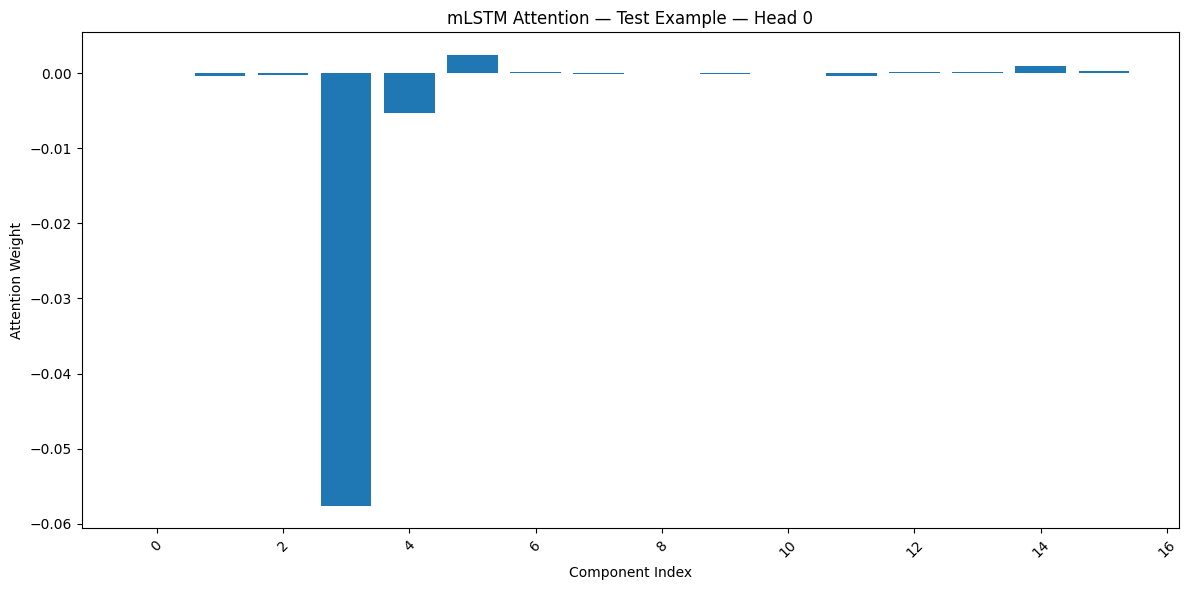

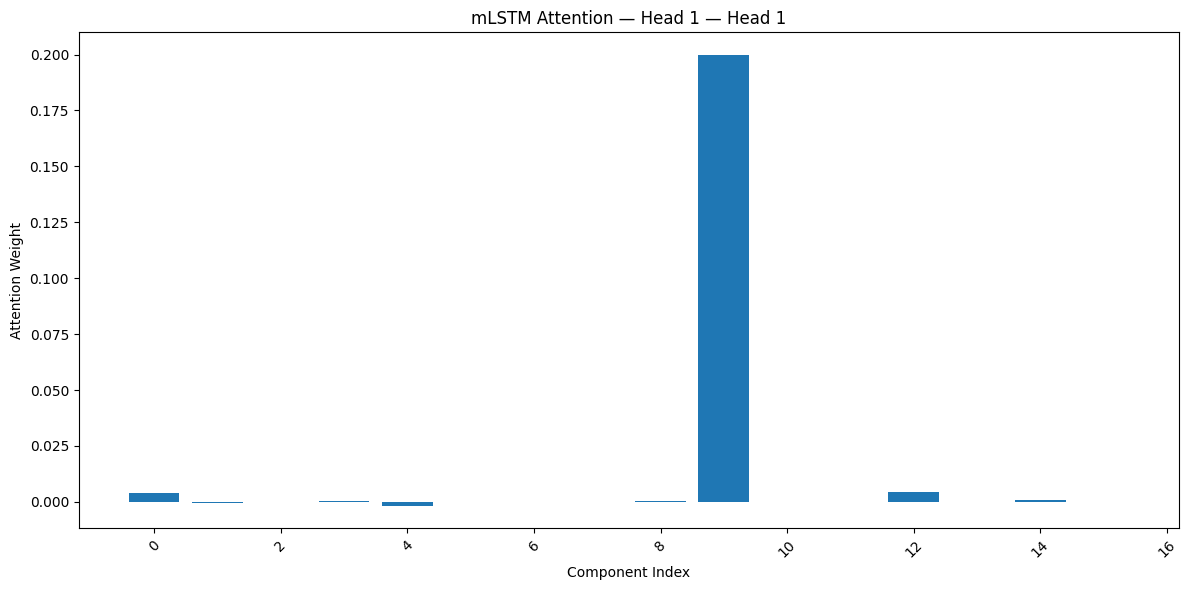

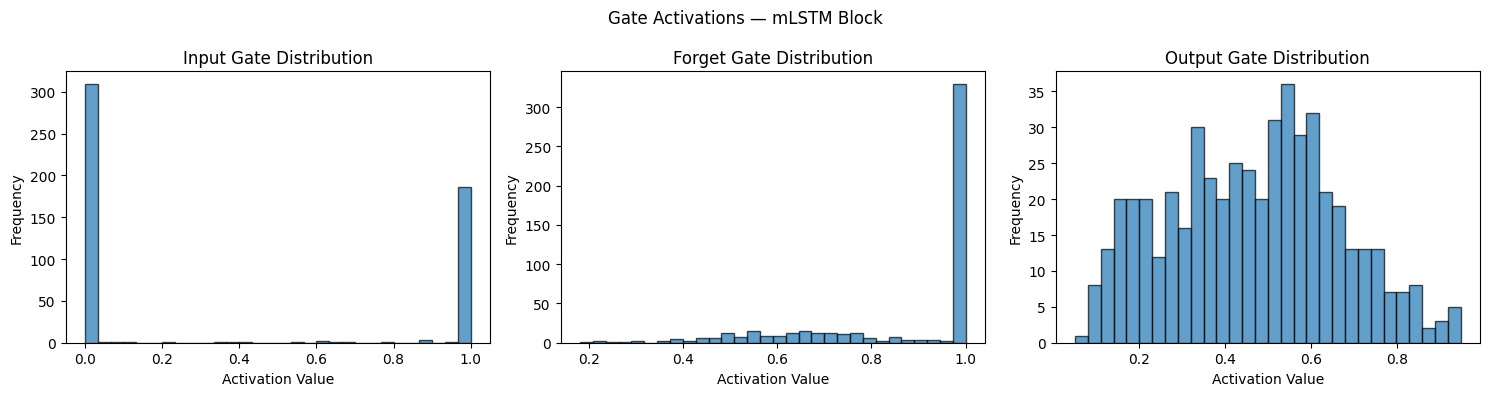


Топ-5 компонентов внимания (Head 0):
  comp_5: 0.0024
  comp_14: 0.0009
  comp_15: 0.0003
  comp_12: 0.0002
  comp_6: 0.0001

Готово! Проверьте файлы attention_head*.png


In [11]:
# ========================
# 2. UTILS ДЛЯ ПРЕПРОЦЕССИНГА И ВИЗУАЛИЗАЦИИ
# ========================

def preprocess_text(text: str) -> list:
    text = re.sub(r'<.*?>', '', text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

def get_tokens_with_positions(text: str, max_len: int) -> list:
    """Возвращает список токенов с их позициями в исходном тексте"""
    tokens = preprocess_text(text)[:max_len]
    return tokens

def plot_attention_heatmap(attention_weights: np.ndarray, tokens: list, 
                          head_idx: int = 0, title: str = "Attention Weights",
                          save_path: str = None):
    """
    Визуализация attention weights для одного head'а.
    attention_weights: [num_heads, head_size] или [seq_len, num_heads, head_size]
    """
    plt.figure(figsize=(12, 6))
    
    # Если attention_weights имеет размерность [seq_len, num_heads, head_size]
    if attention_weights.ndim == 3:
        # Берём среднее по последовательности или последний шаг
        attn = np.mean(attention_weights, axis=0)  # [num_heads, head_size]
    else:
        attn = attention_weights  # [num_heads, head_size]
    
    # Выбираем конкретный head
    head_attn = attn[head_idx]  # [head_size]
    
    # Создаём матрицу: tokens × components
    # Для демонстрации покажем как каждый токен влияет на компоненты attention
    if len(tokens) <= 20:
        # Матрица: tokens (rows) × head_components (cols)
        # Упрощённая визуализация: покажем активацию компонентов для каждого токена
        plot_data = np.tile(head_attn, (len(tokens), 1))  # [num_tokens, head_size]
        
        sns.heatmap(plot_data, 
                   xticklabels=[f'comp_{i}' for i in range(head_attn.shape[0])],
                   yticklabels=tokens if len(tokens) <= 15 else tokens[::max(1, len(tokens)//12)],
                   cmap='YlOrRd', cbar_kws={'label': 'Attention Score'})
        plt.xlabel('Attention Head Components')
        plt.ylabel('Tokens')
    else:
        # Для длинных последовательностей покажем только значения компонентов
        plt.bar(range(len(head_attn)), head_attn)
        plt.xlabel('Component Index')
        plt.ylabel('Attention Weight')
        plt.xticks(rotation=45)
    
    plt.title(f'{title} — Head {head_idx}')
    plt.tight_layout()
    
    plt.show()
    
    plt.close()


def plot_gates_comparison(gates: dict, tokens: list, title: str = "Gate Activations"):
    """Визуализация активаций гейтов (input, forget, output)"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    gate_names = ['input', 'forget', 'output']
    for ax, gate_name in zip(axes, gate_names):
        values = gates[gate_name].flatten()
        # Показываем статистику, если токенов много
        if len(tokens) > 20:
            ax.hist(values, bins=30, edgecolor='black', alpha=0.7)
            ax.set_title(f'{gate_name.capitalize()} Gate Distribution')
            ax.set_xlabel('Activation Value')
            ax.set_ylabel('Frequency')
        else:
            ax.bar(range(len(values)), values)
            ax.set_title(f'{gate_name.capitalize()} Gate per Token')
            ax.set_xlabel('Token Index')
            ax.set_ylabel('Activation')
            ax.set_xticks(range(len(tokens)))
            ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    plt.close()


# ========================
# 3. ОЦЕНКА НА ТЕСТЕ
# ========================

@torch.no_grad()
def evaluate_on_test(model, dataset, fasttext_model, max_len=128, batch_size=32, 
                    device='cpu', sample_idx=None, capture_layer_idx=1):
    """
    Полная оценка + опциональная визуализация на конкретном примере.
    
    Args:
        sample_idx: индекс примера для детального анализа внимания
        capture_layer_idx: индекс слоя xLSTM, в котором нужно захватить attention
    """
    model.eval()
    
    # Подготовка данных
    print("Подготовка тестовых данных...")
    embeddings_list, masks_list, labels_list, texts_list, tokens_list = [], [], [], [], []
    
    for item in tqdm(dataset, desc="Preprocessing test", leave=False):
        tokens = preprocess_text(item['text'])[:max_len]
        tokens_list.append(tokens)
        texts_list.append(item['text'][:200] + "..." if len(item['text']) > 200 else item['text'])
        
        embeddings = []
        for tok in tokens:
            vec = fasttext_model.wv[tok] if tok in fasttext_model.wv else np.zeros(fasttext_model.vector_size)
            embeddings.append(vec)
        
        if len(embeddings) < max_len:
            padding = np.zeros((max_len - len(embeddings), fasttext_model.vector_size), dtype=np.float32)
            embeddings = np.vstack([embeddings, padding])
            mask = [1]*len(tokens) + [0]*(max_len - len(tokens))
        else:
            mask = [1]*max_len
        
        embeddings_list.append(embeddings)
        masks_list.append(mask)
        labels_list.append(item['label'])
    
    # Конвертация в тензоры
    X = torch.from_numpy(np.stack(embeddings_list)).float()
    M = torch.from_numpy(np.stack(masks_list)).float()
    y = torch.tensor(labels_list, dtype=torch.long)
    
    print(f"Тестовая выборка: {len(y)} примеров")
    
    # Батчевая оценка
    all_preds, all_logits = [], []

    saved_attn = None
    saved_gates = None

    for i in tqdm(range(0, len(y), batch_size), desc="Evaluating", leave=False):
        batch_X = X[i:i+batch_size].to(device)
        batch_M = M[i:i+batch_size].to(device)
        
        # 2. Убираем else, который обнулял данные
        if sample_idx is not None and i <= sample_idx < i + batch_size:
            local_idx = sample_idx - i
            # Включаем захват внимания только для целевого батча
            logits = model(batch_X, batch_M, capture_attention=True, capture_layer_idx=capture_layer_idx)
            
            # Извлекаем данные сразу
            target_layer = model.xlstm.layers[capture_layer_idx]
            if hasattr(target_layer, '_saved_attention') and target_layer._saved_attention is not None:
                saved_attn = target_layer._saved_attention[local_idx]   # [num_heads, head_size]
                saved_gates = target_layer._saved_gates
                print(f"Attention захвачен для example #{sample_idx}, shape: {saved_attn.shape}")
        else:
            # Обычный инференс без захвата
            logits = model(batch_X, batch_M)
        
        # 3. Собираем предсказания
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_logits.extend(logits.cpu().numpy())

    
    # Метрики
    acc = accuracy_score(labels_list, all_preds)
    f1 = f1_score(labels_list, all_preds)
    
    print(f"\nРезультаты на тесте:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(labels_list, all_preds, target_names=['Negative', 'Positive']))
    
    # Визуализация конкретного примера

    if sample_idx is not None and saved_attn is not None:

        print('\nsaved attn is done\n')

        print(f"\nВизуализация внимания для примера #{sample_idx}:")
        print(f"  Текст: \"{texts_list[sample_idx]}\"")
        print(f"  True label: {'POSITIVE' if labels_list[sample_idx]==1 else 'NEGATIVE'}")
        print(f"  Pred label: {'POSITIVE' if all_preds[sample_idx]==1 else 'NEGATIVE'}")
        
        tokens = tokens_list[sample_idx]
        print(f"  Токены ({len(tokens)}): {tokens[:15]}{'...' if len(tokens)>15 else ''}")
        
        # Plot 1: Attention heatmap
        plot_attention_heatmap(
            saved_attn, tokens, 
            head_idx=0, 
            title="mLSTM Attention — Test Example",
            save_path="attention_head0.png"
        )
        
        # Plot 2: Если есть второй head
        if saved_attn.shape[0] > 1:
            plot_attention_heatmap(
                saved_attn, tokens,
                head_idx=1,
                title="mLSTM Attention — Head 1",
                save_path="attention_head1.png"
            )
        
        # Plot 3: Gate activations
        if saved_gates:
            plot_gates_comparison(saved_gates, tokens, title="Gate Activations — mLSTM Block")
        
        # Print top attended components
        print(f"\nТоп-5 компонентов внимания (Head 0):")
        head0_attn = saved_attn[0]
        top_indices = np.argsort(head0_attn)[-5:][::-1]
        for idx in top_indices:
            print(f"  comp_{idx}: {head0_attn[idx]:.4f}")
    
    return acc, f1, all_preds




EMBEDDING_DIM = 100
HEAD_SIZE = 16
NUM_HEADS = 2
LAYERS = ('s', 'm')
HIDDEN_DIM = 64
MAX_LEN = 128
DEVICE = torch.device('cpu')

print(f"Запуск оценки на {DEVICE}")

# Загрузка FastText
print("Загрузка FastText модели...")
try:
    ft_model = FastText.load("imdb_fasttext.model")
except FileNotFoundError:
    print("Модель FastText не найдена. Сначала обучите её.")
    

# Загрузка теста
print("Загрузка тестового датасета...")
test_dataset = load_dataset('stanfordnlp/imdb', split='test')
print(f"Загружено {len(test_dataset)} тестовых примеров")

# Загрузка модели
print("Загрузка обученной модели...")
model = IMDBClassifierVisualizable(
    embedding_dim=EMBEDDING_DIM,
    head_size=HEAD_SIZE,
    num_heads=NUM_HEADS,
    layers=LAYERS,
    hidden_dim=HIDDEN_DIM
)

try:
    model.load_state_dict(torch.load("xlstm_imdb_cpu_best.pt", map_location=DEVICE))
    print("Модель загружена")
except FileNotFoundError:
    print("Файл модели не найден, используем случайные веса (для демонстрации)")

model.to(DEVICE)

# Оценка + визуализация
# Укажите sample_idx для детального анализа конкретного примера
SAMPLE_IDX = 42  # Пример для визуализации внимания
CAPTURE_LAYER = 1  # Индекс mLSTM-слоя в архитектуре ('s','m') → 1

evaluate_on_test(
    model, test_dataset, ft_model,
    max_len=MAX_LEN,
    batch_size=16,
    device=DEVICE,
    sample_idx=SAMPLE_IDX,
    capture_layer_idx=CAPTURE_LAYER
)

print("\nГотово! Проверьте файлы attention_head*.png")




Поисследуем графики распределения весов гейтов:
1. Входящий гейт, почти все веса это 0 или 1, значит модель точно определяет будет ли полезна та или иная информация для определения таргета, но бОльшая часть весов равна 0, это объяснимо так как в комментариях только несколько слов показывают отрицательность комментария, остальная часть текста про объяснение ошибок, аргументирование позиции

2. Гейт забывания, очень много весов равна 1, то есть модель почти ничего не забывает проходя через новую информацию. Это тоже понятно почему, как правило настроение комментария задается в начале и модели нужно сохранить этот контекст до конца комментария

3. Выходной гейт, веса распределены нормально вокруг 0.5, модель выбирает из длинного контекста что влияет на таргет а что нет, это дефолтное распределение весов


В целом модель не очень хорошо определяет таргет, но это связано с тем что возможно плохо подобраны гипер параметры, а так же мб плохая токенизация текста

Веса внимания не очень хорошо интерпретируются так как непонятно чему соответствует та или иная координата голов внимания